# Simple Data Visualization & Benford's Law #

$Author$: Michael Simons

$Student ID$: 50317142

$Class$: MTH 337

$Date$: 11/24/22

## Introduction
Software systems designed for processing and organizing data have recently lead to an abundance of innovation and discovery across many fields. These modern data science tools provide convenient and practical approaches of applying mathematics through the analysis of data.

This report will aim to demonstrate the powerful functionality of these tools through meaningful analysis of text and demonstration of data visualization.

## First digit, Last digit
The analysis in this report will consist of observing the frequencies in which digits show up as the first or last non-zero digit in numbers. Prior to the analysis, we must develop tools to identify which digit is first or last.

The idea behind this is straightforward. Converting a number to a string will allow for iteration until a non-zero character is found. Since numbers can be negative and have decimal values, the symbols `-` and `.` will also be accounted for.

In [1]:
#Given a number, returns the first non-zero digit
def fd(n):
    for char in str(n):                            #Convert the number to a string and iterate over the characters
        if(char!='-' and char!='.' and char!='0'): #Assert that the first non-zero digit is found
            return int(char)                       #Return it as an integer
    return 0                                       #Return 0 if no non-zeros are found
print(f'Testing fd function...\nThe first non-zero digit of {123.45} is: {fd(123.45)}\nThe first non-zero digit of {-75} is: {fd(-75)}\nThe first non-zero digit of {0.00345} is: {fd(0.00345)}\nThe first non-zero digit of {0.0} is: {fd(0.0)}')

Testing fd function...
The first non-zero digit of 123.45 is: 1
The first non-zero digit of -75 is: 7
The first non-zero digit of 0.00345 is: 3
The first non-zero digit of 0.0 is: 0


The tests show that the function correctly finds the first non-zero digit. The last non-zero digit can be found by simply iterating over the string's characters in reverse order. The `ld` function will also be constructed for future usage.

In [2]:
#Given a number, returns the last non-zero digit
def ld(n):
    for char in str(n)[::-1]:                      #Convert the number to a string and iterate over the characters in reverse
        if(char!='-' and char!='.' and char!='0'): #Assert that the a non-zero digit is found
            return int(char)                       #Return it as an integer
    return 0                                       #Return 0 if no non-zeros are found
print(f'Testing ld function...\nThe last non-zero digit of {-123.45} is: {ld(-123.45)}\nThe last non-zero digit of {42000.00} is: {ld(42000.00)}\nThe last non-zero digit of {0.0} is: {ld(0.0)}\nThe last non-zero digit of {0.00345} is: {ld(0.00345)}')

Testing ld function...
The last non-zero digit of -123.45 is: 5
The last non-zero digit of 42000.0 is: 2
The last non-zero digit of 0.0 is: 0
The last non-zero digit of 0.00345 is: 5


## Part 1

This section will utilize the `fd` and `ld` functions to analyze how often numbers appear as the first and last digit in multiple data sources. A necessary start will be extracting data from a CSV file which contains a list of countries and their population over a period of time. Using Pandas to visualize the formatting of the file will be advantageous.

In [3]:
import pandas as pd              #Will be used to read csv files and visualize data
import matplotlib.pyplot as plt  #Will be used to visualize data
df_cp = pd.read_csv("country_populations.csv",delimiter=",", header=None) #Initialize a dataframe to store and visualize data
df_cp=df_cp.fillna(0)            #Fill null values to avoid error. Use of 0 will prevent skewing the data
df_cp

,0,1,2,3,4,5,6,7,8,9,...,47,48,49,50,51,52,53,54,55,56
0,Country Name,Country Code,1960.0,1961.0,1962.0,1963.0,1964.0,1965.0,1966.0,1967.0,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
1,Afghanistan,AFG,8994793.0,9164945.0,9343772.0,9531555.0,9728645.0,9935358.0,10148841.0,10368600.0,...,24399948,25183615,25877544,26528741,27207291,27962207,28809167,29726803,30682500,31627506
2,Albania,ALB,1608800.0,1659800.0,1711319.0,1762621.0,1814135.0,1864791.0,1914573.0,1965598.0,...,3011487,2992547,2970017,2947314,2927519,2913021,2904780,2900489,2897366,2894475
3,Algeria,DZA,11124892.0,11404859.0,11690152.0,11985130.0,12295973.0,12626953.0,12980269.0,13354197.0,...,33267887,33749328,34261971,34811059,35401790,36036159,36717132,37439427,38186135,38934334
4,American Samoa,ASM,20012.0,20478.0,21118.0,21883.0,22701.0,23518.0,24320.0,25116.0,...,59117,58648,57904,57031,56226,55636,55316,55227,55302,55434
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
207,Vietnam,VNM,34743000.0,35428000.0,36123000.0,36836000.0,37574000.0,38341000.0,39142000.0,39980000.0,...,82392100,83311200,84218500,85118700,86025000,86932500,87840000,88772900,89708900,90730000
208,Virgin Islands (U.S.),VIR,32000.0,34100.0,36300.0,38700.0,41300.0,44000.0,47300.0,50800.0,...,107863,107700,107423,107091,106707,106267,105784,105275,104737,104170
209,"Yemen, Rep.",YEM,5166311.0,5251663.0,5339285.0,5429501.0,5522690.0,5619170.0,5720538.0,5827223.0,...,20504385,21093973,21701105,22322699,22954226,23591972,24234940,24882792,25533217,26183676
210,Zambia,ZMB,3049586.0,3142848.0,3240664.0,3342894.0,3449266.0,3559687.0,3674088.0,3792864.0,...,12043591,12381509,12738676,13114579,13507849,13917439,14343526,14786581,15246086,15721343


The data frame above shows the format of the extracted data. The first row contains a list of years from 1960 - 2014, and the rest of the rows contain the names of countries and their population during each respective year. All numbers in the file, excluding the row containing the years, will be examined. Two dictionaries will be initialized to monitor the frequency of each number appearing as the first or last non-zero digit.

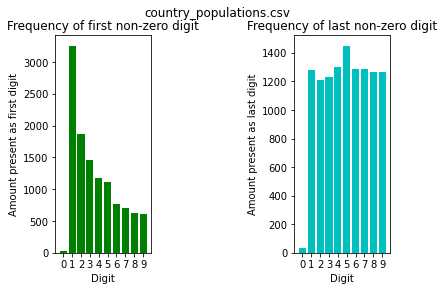

In [4]:
dfd={0:0,1:0,2:0,3:0,4:0,5:0,6:0,7:0,8:0,9:0}      #Initialize dictionary for first digits
dld={0:0,1:0,2:0,3:0,4:0,5:0,6:0,7:0,8:0,9:0}      #Initialize dictionary for last digits
for i in range(2,57):                              #Loop through all columns of the data frame
    for k in df_cp[i][1:]:                         #Loop through each row (except the first row being the years)
        dfd[fd(k)]=dfd[fd(k)]+1                    #Compute first/last digits and increment both dictionaries
        dld[ld(k)]=dld[ld(k)]+1
x1=[k for k in dfd.keys()]
y1=[dfd[a] for a in x1]                            #Accumulate values for both bar plots
x2=[k for k in dld.keys()]
y2=[dld[a] for a in x2]
plt.subplot(1,2,1)                                 #Initialize 1x2 subplot
plt.title("Frequency of first non-zero digit")
plt.ylabel("Amount present as first digit")
plt.xlabel("Digit")
plt.bar(x1,y1,color='g',tick_label=x1)
plt.subplot(1,2,2)                                 #Update to 2nd plot
plt.title("Frequency of last non-zero digit")
plt.ylabel("Amount present as last digit")
plt.xlabel("Digit")
plt.bar(x2,y2,color='c',tick_label=x2)
plt.subplots_adjust(wspace=1.5)
plt.suptitle("country_populations.csv")
plt.show();
#Note: the 0 digit will be skewed and is only added when a non-zero is not found

From the bar plots, there are some interesting observations to consider. The frequency of the first non-zero digit was by far the highest for the digit 1, following a pattern of lower frequency as the digit got higher. It is not completely certain why this pattern is present, although it is likely due to the simple fact that a country is more likely to have a population 10 million people than a population 90 million.

In the case of the last non-zero digits, there is a significantly more normal distribution among the numbers in comparison to the pattern found in the first digits.

## Part 2
To futher explore the findings, we will produce more results to compare them with. It will help extract number values from a text file containing New York Times articles. Regular expressions will be a particularly powerful and efficient tool for this task.

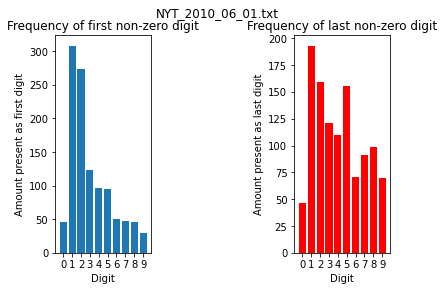

In [5]:
import re                              #Will be used to search for numbers in the text file
numbers=[]                             #Initialize empty structure to accumulate numbers
with open("NYT_2010_06_01.txt") as f:  #Open the text file
    for r in f:                        #Iterate through rows of the file
        for n in re.findall(r'\b\d\d*?\b',r):      #Regular expression which finds all numbers surrounded by non-digits
            numbers.insert(0,n)                    #Insert each number to the head of the accumulator
dfd={0:0,1:0,2:0,3:0,4:0,5:0,6:0,7:0,8:0,9:0}      #Initialize dictionary for first digits
dld={0:0,1:0,2:0,3:0,4:0,5:0,6:0,7:0,8:0,9:0}      #Initialize dictionary for last digits
for n in numbers:                                  #Iterate through the numbers, compute first and last digits
    dfd[fd(n)]=dfd[fd(n)]+1                        
    dld[ld(n)]=dld[ld(n)]+1
x1=[k for k in dfd.keys()]
x2=[k for k in dld.keys()]                         #Gather x,y values for the bar plots
y1=[dfd[a] for a in x1]
y2=[dld[a] for a in x2]
plt.subplot(1,2,1)                                 #Init. 1x2 subplot
plt.title("Frequency of first non-zero digit")
plt.ylabel("Amount present as first digit")
plt.xlabel("Digit")
plt.bar(x1,y1,tick_label=x1)
plt.subplot(1,2,2)                                 #Update to 2nd plot
plt.title("Frequency of last non-zero digit")
plt.ylabel("Amount present as last digit")
plt.xlabel("Digit")
plt.bar(x2,y2,color='r',tick_label=x2)
plt.subplots_adjust(wspace=1.5)
plt.suptitle("NYT_2010_06_01.txt")
plt.show();

As expected, the bar graph of first non-zero digits shows the descending pattern similar to our previous results. To some surprise, the pattern is also present in the frequency of last non-zero digit graph.

The intuitive thought was that there must be outliers numbers, which show up many times and skew the results. However, after examining the `numbers` structure, it consists mostly of unique numbers. Even upon further investigation, the reasoning behing why this pattern would be present in the last digit graph is unclear.

Another notable observation is that 0 seems to appear significantly more frequently in these results.

## Plotting Airports Using Coordinate Data
`airports.csv` is a file which contains the coordinates of a large number of airports around the world in the form of longitude and latitude. An interesting demonstration is visualizing the airports on a scatter plot.

In [6]:
df_a = pd.read_csv("airports.csv",delimiter=",", header=2, encoding='latin1') #Initialize a dataframe to store airports
df_a

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,gps_code,iata_code,local_code
0,6523,00A,heliport,Total Rf Heliport,40.070801,-74.933601,11.0,NaN,US,US-PA,Bensalem,no,00A,NaN,00A
1,6524,00AK,small_airport,Lowell Field,59.949200,-151.695999,450.0,NaN,US,US-AK,Anchor Point,no,00AK,NaN,00AK
2,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820.0,NaN,US,US-AL,Harvest,no,00AL,NaN,00AL
3,6526,00AR,heliport,Newport Hospital & Clinic Heliport,35.608700,-91.254898,237.0,NaN,US,US-AR,Newport,no,00AR,NaN,00AR
4,6527,00AZ,small_airport,Cordes Airport,34.305599,-112.165001,3810.0,NaN,US,US-AZ,Cordes,no,00AZ,NaN,00AZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47531,27244,ZYYJ,medium_airport,Yanji Chaoyangchuan Airport,42.882801,129.451004,624.0,AS,CN,CN-22,Yanji,yes,ZYYJ,YNJ,NaN
47532,32753,ZYYY,medium_airport,Shenyang Dongta Airport,41.784401,123.496002,NaN,AS,CN,CN-21,Shenyang,no,ZYYY,NaN,NaN
47533,46378,ZZ-0001,heliport,Sealand Helipad,51.894444,1.482500,40.0,EU,GB,GB-ENG,Sealand,no,NaN,NaN,NaN
47534,307326,ZZ-0002,small_airport,Glorioso Islands Airstrip,-11.584278,47.296389,11.0,AF,TF,TF-U-A,Grande Glorieuse,no,NaN,NaN,NaN


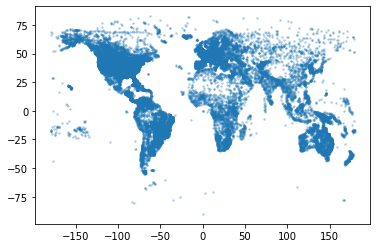

In [7]:
x_values=df_a["longitude_deg"]            #Grab long. coords
y_values=df_a["latitude_deg"]             #Grab lat. coords
plt.scatter(x_values,y_values,s=2.5,alpha=0.25) #Scatter plot, smaller and transparancy
plt.show();

## Conclusion
Data visualization and examination of first and last non-zero digits is just one basic example of many complex ways numerical data can be analyzed.The anomalies highlighted in this report in reference to first digits and last digits is commonly known as Benford's Law, which is an observation that in many real-life sets of numerical data, the leading digit is likely to be small. In sets that obey this law, the number 1 appears as the leading significant digit about 30% of the time, while 9 appears as the leading significant digit less than 5% of the time. With the constant development of innovative data science software and research, computation's role in both research and application of mathematics has become essential.

## References ##

[1] https://mathworld.wolfram.com/BenfordsLaw.html